# Analysis of Automotive Test Data

This notebook combines SQL + Python using DuckDB.


In [3]:
import os

os.listdir("..")

['.venv',
 'automotive.duckdb',
 'data',
 'my_database.duckdb',
 'notebooks',
 'queries',
 'README.md',
 'schema',
 'sql']

In [5]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the DuckDB database file
con = duckdb.connect(r"C:\Users\monta\Documents\Development\GitHub\process-data-sql-lab-main\process-data-sql-lab-main\my_database.duckdb")
con.execute("SHOW TABLES").df()


,name
0,anomalies
1,components
2,sensor_readings
3,test_runs
4,vehicles


In [6]:
con.sql("DESCRIBE sensor_readings").df()


,column_name,column_type,null,key,default,extra
0,reading_id,INTEGER,YES,None,None,None
1,test_run_id,INTEGER,YES,None,None,None
2,timestamp,TIMESTAMP,YES,None,None,None
3,sensor_type,VARCHAR,YES,None,None,None
4,value,FLOAT,YES,None,None,None


In [7]:
con.sql("SELECT * FROM sensor_readings LIMIT 10").df()


,reading_id,test_run_id,timestamp,sensor_type,value
0,1,1,2023-01-10 08:00:01,temperature,18.700001
1,2,1,2023-01-10 08:00:03,voltage,398.200012
2,3,1,2023-01-10 08:00:05,current,112.400002
3,4,1,2023-01-10 08:00:07,vibration,0.320000
4,5,1,2023-01-10 08:00:09,temperature,18.799999
5,6,1,2023-01-10 08:00:11,voltage,397.899994
6,7,1,2023-01-10 08:00:13,current,113.099998
7,8,1,2023-01-10 08:00:15,vibration,0.350000
8,9,1,2023-01-10 08:00:17,temperature,18.900000
9,10,1,2023-01-10 08:00:19,voltage,398.000000


In [8]:
df = con.sql("""
    SELECT timestamp, value
    FROM sensor_readings
    WHERE sensor_type = 'temperature'
""").df()


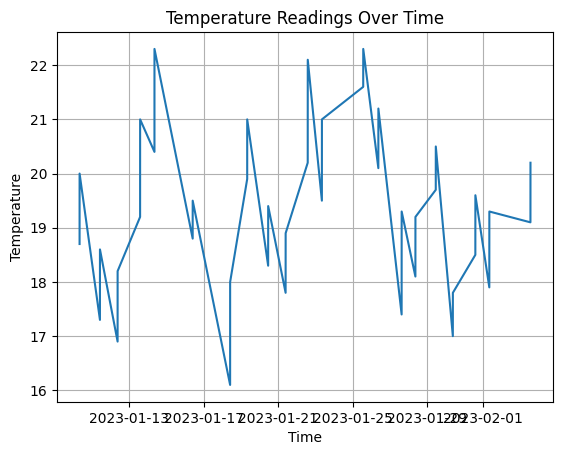

In [9]:
# Plot sensor readings, type = temperature, over time
df = con.sql("""
    SELECT timestamp, value
    FROM sensor_readings
    WHERE sensor_type = 'temperature'
    ORDER BY timestamp
""").df()

plt.plot(df["timestamp"], df["value"])
plt.title("Temperature Readings Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.grid(True)
plt.show()


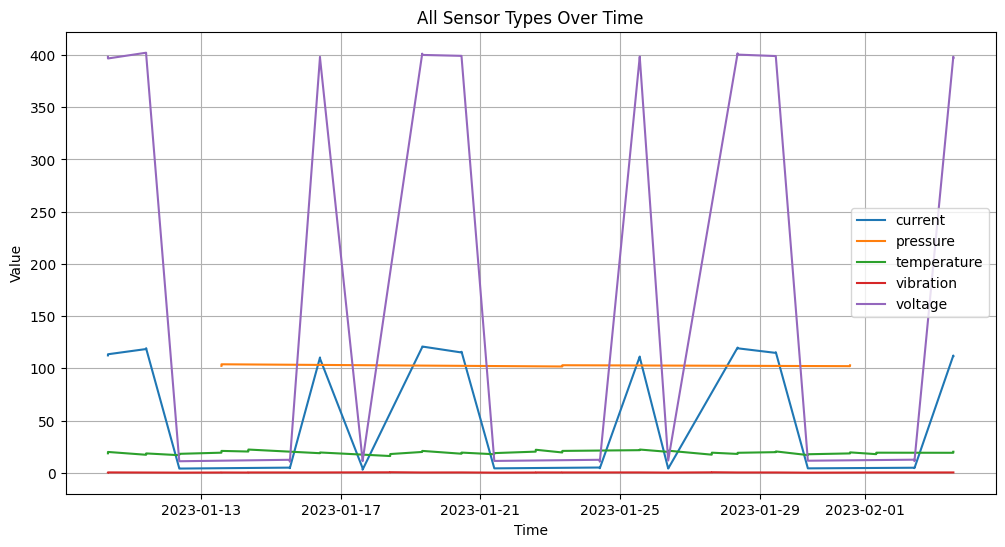

In [10]:
# Compare the different sensors over time
%matplotlib inline
import matplotlib.pyplot as plt

df = con.sql("""
    SELECT timestamp, sensor_type, value
    FROM sensor_readings
    ORDER BY timestamp
""").df()

plt.figure(figsize=(12,6))

for sensor, group in df.groupby("sensor_type"):
    plt.plot(group["timestamp"], group["value"], label=sensor)

plt.title("All Sensor Types Over Time")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


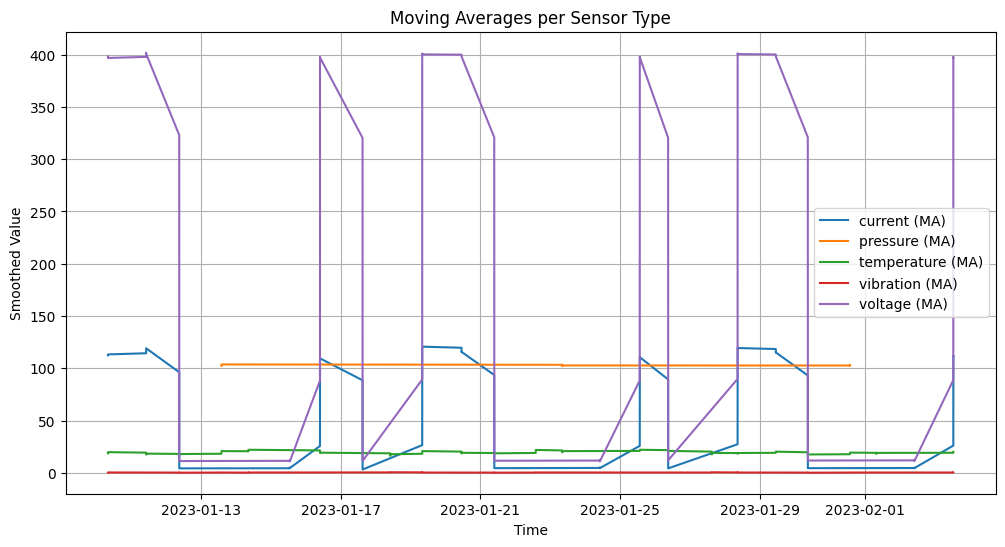

In [11]:
#  computing moving averages, for each sensor type
import pandas as pd

df_ma = df.copy()
df_ma["moving_avg"] = df_ma.groupby("sensor_type")["value"].transform(
    lambda x: x.rolling(window=5, min_periods=1).mean()
)

plt.figure(figsize=(12,6))

for sensor, group in df_ma.groupby("sensor_type"):
    plt.plot(group["timestamp"], group["moving_avg"], label=f"{sensor} (MA)")

plt.title("Moving Averages per Sensor Type")
plt.xlabel("Time")
plt.ylabel("Smoothed Value")
plt.legend()
plt.grid(True)
plt.show()



In [12]:
#  Compute rolling standart deviation, similarly to mean (average)
df_stats = df.copy()

df_stats["rolling_std"] = df_stats.groupby("sensor_type")["value"].transform(
    lambda x: x.rolling(window=5, min_periods=1).std()
)


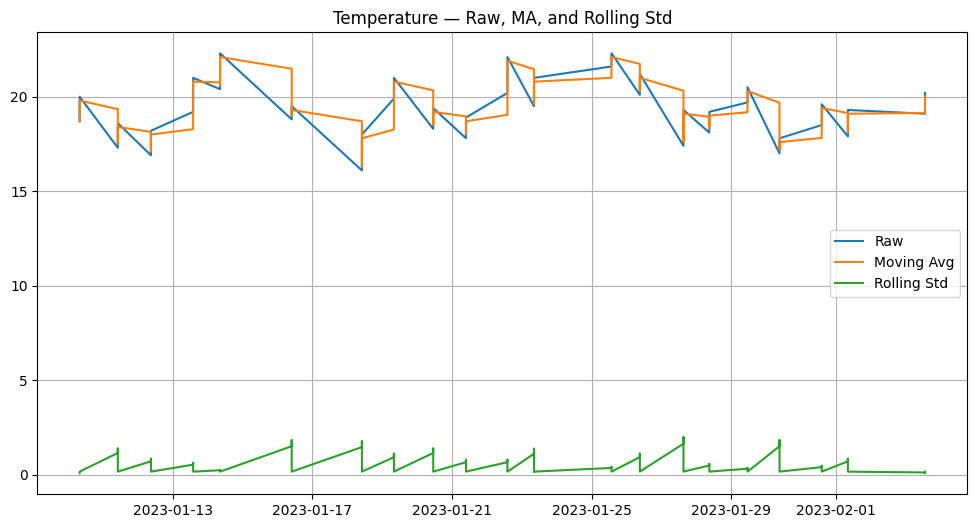

In [13]:
#  Visualization of  sensor_type (temperature) 
sensor = "temperature"
subset = df_stats[df_stats["sensor_type"] == sensor]

%matplotlib inline
plt.figure(figsize=(12,6))
plt.plot(subset["timestamp"], subset["value"], label="Raw")
plt.plot(subset["timestamp"], subset["moving_avg"], label="Moving Avg")
plt.plot(subset["timestamp"], subset["rolling_std"], label="Rolling Std")
plt.legend()
plt.grid(True)
plt.title(f"{sensor.capitalize()} — Raw, MA, and Rolling Std")
plt.show()


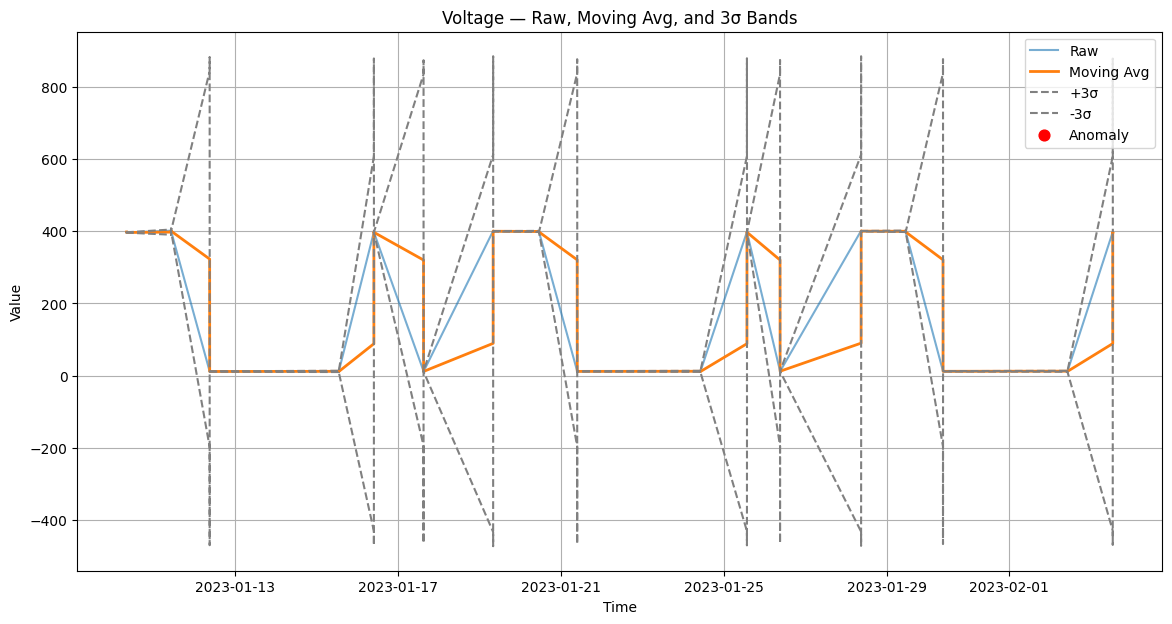

In [14]:
df_stats["is_anomaly"] = (
    abs(df_stats["value"] - df_stats["moving_avg"]) > 3 * df_stats["rolling_std"]
)


df_stats["upper_3sigma"] = df_stats["moving_avg"] + 3 * df_stats["rolling_std"]
df_stats["lower_3sigma"] = df_stats["moving_avg"] - 3 * df_stats["rolling_std"]


df_stats["is_anomaly"] = (
    (df_stats["value"] > df_stats["upper_3sigma"]) |
    (df_stats["value"] < df_stats["lower_3sigma"])
)

sensor = "voltage"
subset = df_stats[df_stats["sensor_type"] == sensor]

plt.figure(figsize=(14,7))

# Raw signal
plt.plot(subset["timestamp"], subset["value"], label="Raw", alpha=0.6)

# Moving average
plt.plot(subset["timestamp"], subset["moving_avg"], label="Moving Avg", linewidth=2)

# 3-sigma bands
plt.plot(subset["timestamp"], subset["upper_3sigma"], label="+3σ", linestyle="--", color="gray")
plt.plot(subset["timestamp"], subset["lower_3sigma"], label="-3σ", linestyle="--", color="gray")

# Anomalies
anoms = subset[subset["is_anomaly"]]
plt.scatter(anoms["timestamp"], anoms["value"], color="red", s=60, label="Anomaly")

plt.title(f"{sensor.capitalize()} — Raw, Moving Avg, and 3σ Bands")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()



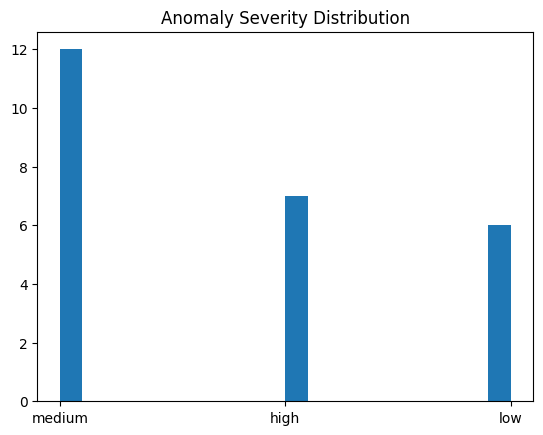

In [15]:
# Plot a Histogram of anomalies
df = con.sql("SELECT severity FROM anomalies").df()

plt.hist(df["severity"], bins=20)
plt.title("Anomaly Severity Distribution")
plt.show()


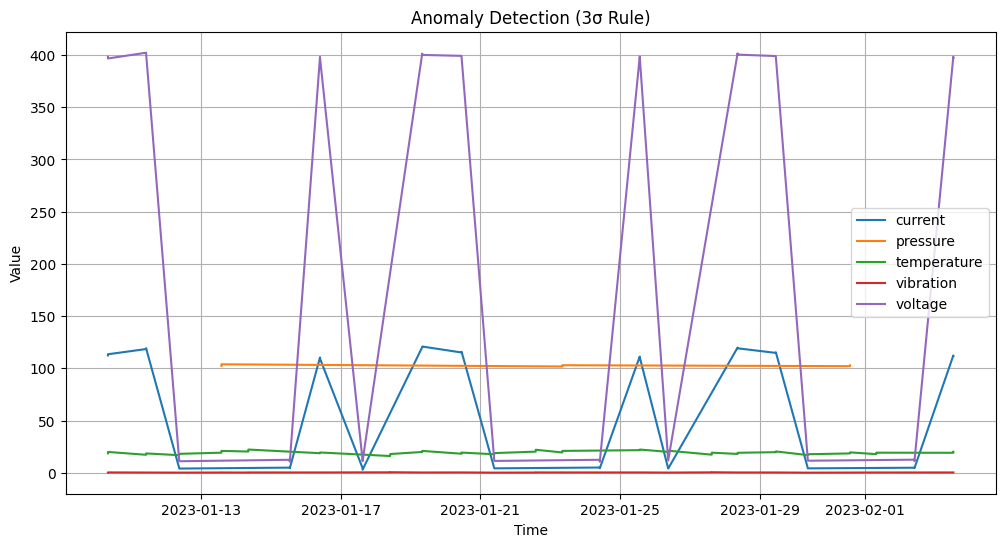

In [17]:
df_an = df_stats.copy()


stats = df_an.groupby("sensor_type")["value"].agg(["mean", "std"])
df_an = df_an.join(stats, on="sensor_type")

df_an["is_anomaly"] = abs(df_an["value"] - df_an["mean"]) > 3 * df_an["std"]


plt.figure(figsize=(12,6))

for sensor, group in df_an.groupby("sensor_type"):
    plt.plot(group["timestamp"], group["value"], label=sensor)
    anomalies = group[group["is_anomaly"]]
    plt.scatter(anomalies["timestamp"], anomalies["value"], color="red", s=50)

plt.title("Anomaly Detection (3σ Rule)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


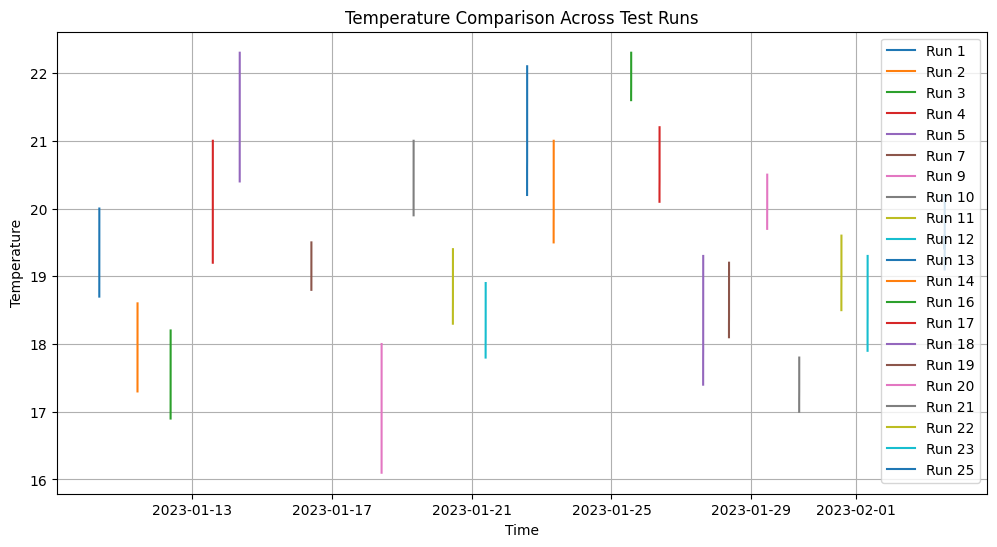

In [18]:
# Compare test runs for sensor_type= temperature over time
df_temp = con.sql("""
    SELECT test_run_id, timestamp, value
    FROM sensor_readings
    WHERE sensor_type = 'temperature'
    ORDER BY timestamp
""").df()

plt.figure(figsize=(12,6))

for run, group in df_temp.groupby("test_run_id"):
    plt.plot(group["timestamp"], group["value"], label=f"Run {run}")

plt.title("Temperature Comparison Across Test Runs")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()


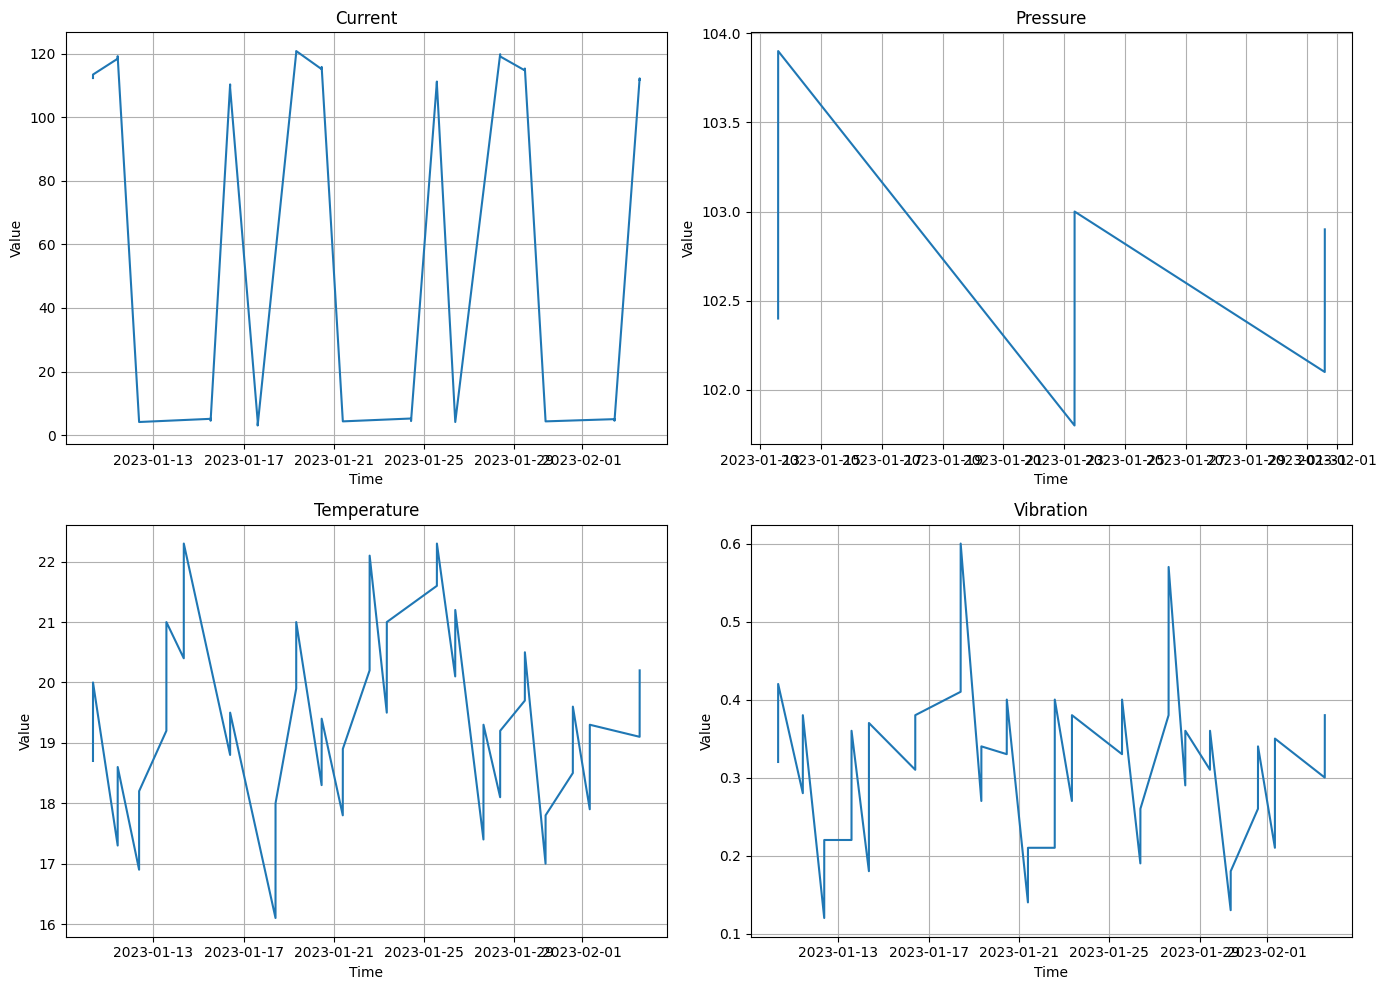

In [23]:
# dashboard‑like layout 2x2 for different sensor_types
df_an = df_stats.copy()

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for ax, (sensor, group) in zip(axes, df_an.groupby("sensor_type")):
    ax.plot(group["timestamp"], group["value"])
    ax.set_title(sensor.capitalize())
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.grid(True)

plt.tight_layout()
plt.show()
